# PEC cavity regression validation

This example reproduces the simulation setup of `tests/test_001_pec_cubic_cavity.py` with the current Wakis implementation and compares the result against the regression data stored in that test.

The purpose is to show why the stored wake-potential and impedance samples change after the dual-grid and high-side PEC boundary corrections.

The current solution is compared against:

- the **previous regression data** stored in `test_001_pec_cubic_cavity.py`;
- the **analytical resonance frequencies** of the rectangular PEC cavity.

The cavity dimensions are obtained directly from the STL bounds, so no dimensions are hard-coded for the analytical reference.

In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from scipy.constants import c

from wakis import GridFIT3D, SolverFIT3D, WakeSolver

from pathlib import Path

repo_root = Path.cwd()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

## Previous regression data

The arrays below are the stored regression samples from `tests/test_001_pec_cubic_cavity.py`.

The test compares

- `wake.WP[::50]` against `WP_reference`;
- `wake.Z[::20]` against `Z_reference`.

Connecting the regression samples with a thin dashed line makes small resonance shifts easier to see while the original sample locations remain visible as markers.

In [5]:
WP_reference = np.array(
    [
        -9.44332595e-17,
        -1.90593430e-14,
        -2.92432824e-12,
        -2.85966621e-10,
        -1.78775256e-08,
        -7.15669085e-07,
        -1.83583718e-05,
        -3.01738609e-04,
        -3.17451120e-03,
        -2.13264221e-02,
        -9.09471961e-02,
        -2.42170990e-01,
        -3.80942164e-01,
        -2.70215476e-01,
        1.63723476e-01,
        5.86828703e-01,
        5.78425842e-01,
        1.40326739e-01,
        -3.14918593e-01,
        -4.14008552e-01,
        -1.00341426e-01,
        3.47488664e-01,
        4.55707614e-01,
        3.12301510e-02,
        -4.67954590e-01,
        -4.14751349e-01,
        1.31785366e-01,
        4.91686569e-01,
        2.79958815e-01,
        -1.96277565e-01,
        -4.33751390e-01,
        -2.40362919e-01,
        2.04148362e-01,
        4.73990162e-01,
        2.26365693e-01,
        -3.22863060e-01,
        -5.14151085e-01,
        -8.56697123e-02,
        4.28214666e-01,
        4.18693782e-01,
        -3.63103145e-02,
        -4.03970520e-01,
        -3.49289428e-01,
        4.75824918e-02,
        4.22758055e-01,
        3.69793808e-01,
        -1.28731294e-01,
        -5.18144741e-01,
        -2.93339490e-01,
        2.82700986e-01,
        5.00387114e-01,
        1.45041055e-01,
        -3.21364175e-01,
        -4.20348811e-01,
        -1.05629844e-01,
        3.20952689e-01,
        4.44675483e-01,
        7.38541659e-02,
        -4.30011048e-01,
        -4.47382113e-01,
        7.89662940e-02,
        4.99504584e-01,
        3.21308113e-01,
        -1.86062433e-01,
        -4.45060460e-01,
        -2.44846000e-01,
        1.88536046e-01,
        4.51379995e-01,
        2.47529690e-01,
        -2.72913212e-01,
        -5.17073038e-01,
        -1.42964155e-01,
        4.07066400e-01,
        4.58068049e-01,
        -8.11280162e-03,
        -4.13854650e-01,
        -3.59550001e-01,
        4.03289095e-02,
        4.00914687e-01,
        3.69118465e-01,
        -8.31046304e-02,
        -4.92825246e-01,
        -3.37255129e-01,
        2.36689164e-01,
        5.21574819e-01,
        1.88715987e-01,
        -3.19144678e-01,
        -4.37645870e-01,
        -1.12207153e-01,
        3.07143625e-01,
        4.30919175e-01,
        1.02079124e-01,
        -3.86863965e-01,
        -4.64999222e-01,
        2.10214892e-02,
        4.92317381e-01,
    ]
)

Z_reference = np.array(
    [
        -5.12228082e00 + 0.0j,
        8.74802421e-01 + 5.64167799j,
        -2.29034622e00 + 3.14009729j,
        -4.28204864e00 + 13.49615494j,
        2.32502792e00 + 13.321102j,
        -5.36792535e00 + 14.68933047j,
        -1.17714699e00 + 25.72710812j,
        1.43437646e00 + 20.50530279j,
        -7.38252819e00 + 28.80590918j,
        2.89251921e00 + 36.04913828j,
        -1.95806099e00 + 29.12426822j,
        -6.92833532e00 + 44.94792056j,
        6.39622577e00 + 44.20261146j,
        -7.26872064e00 + 41.10070955j,
        -3.07547564e00 + 61.92576056j,
        7.45466785e00 + 50.83926611j,
        -1.30126832e01 + 58.25532521j,
        4.35193653e00 + 78.05791427j,
        4.12745568e00 + 57.82811987j,
        -1.67543448e01 + 81.99904217j,
        1.43894531e01 + 91.47524504j,
        -5.17740910e00 + 68.63401325j,
        -1.51213462e01 + 112.98799433j,
        2.44580766e01 + 100.65983537j,
        -2.11205720e01 + 88.87548838j,
        -3.86583900e00 + 150.7750233j,
        2.96814665e01 + 105.41704079j,
        -4.25414436e01 + 127.44216196j,
        2.21346007e01 + 193.52299164j,
        2.15440874e01 + 108.86061213j,
        -6.48125798e01 + 199.53903442j,
        6.94170396e01 + 237.94436543j,
        -1.60152482e01 + 122.63894239j,
        -7.54404758e01 + 337.75127188j,
        1.49497564e02 + 280.07236224j,
        -1.24084853e02 + 187.88759905j,
        -3.32632999e01 + 652.35640735j,
        3.06764067e02 + 321.36800633j,
        -5.31737679e02 + 560.55823748j,
        4.56077028e02 + 2304.80902956j,
        3.19267822e03 + 897.87015732j,
        1.88671765e03 - 2277.05835854j,
        -7.86859618e02 - 1290.30287787j,
        5.66636366e01 + 207.07935809j,
        3.59985611e02 - 685.87627934j,
        -4.57196960e02 - 245.5963575j,
        2.43368571e02 + 163.79602585j,
        7.57041898e01 - 486.50523561j,
        -3.17335611e02 + 90.50517683j,
        3.21226858e02 + 69.69050002j,
    ]
)

## Reproduce the current Wakis simulation

The simulation setup below follows `test_001_pec_cubic_cavity.py`:

- mesh: $50 \times 50 \times 150$ cells;
- cavity STL: `tests/stl/001_cubic_cavity.stl`;
- cavity material: vacuum;
- background: PEC;
- all six outer boundaries: PEC;
- on-axis relativistic Gaussian bunch;
- wake length: $1\,\mathrm{m}$.

The STL bounds are also used later as the analytical cavity dimensions.

In [7]:
dtype = np.float32

Nx = 50
Ny = 50
Nz = 150

stl_file = repo_root / "tests" / "stl" / "001_cubic_cavity.stl"
surf = pv.read(str(stl_file))

stl_solids = {"cavity": str(stl_file)}
stl_materials = {"cavity": "vacuum"}

xmin, xmax, ymin, ymax, zmin, zmax = surf.bounds

a = xmax - xmin
b = ymax - ymin
d = zmax - zmin

print("Cavity dimensions:")
print(f"  a = {a:.6g} m")
print(f"  b = {b:.6g} m")
print(f"  d = {d:.6g} m")

grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax,
    Nx,
    Ny,
    Nz,
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    verbose=2,
)

beta = 1.0
sigmaz = 18.5e-3 * beta
q = 1e-9

xs = 0.0
ys = 0.0
xt = 0.0
yt = 0.0

skip_cells = 12
wakelength = 1.0

ez_file = repo_root / "tests" / "001_Ez.h5"

wake = WakeSolver(
    wakelength=wakelength,
    q=q,
    sigmaz=sigmaz,
    beta=beta,
    xsource=xs,
    ysource=ys,
    xtest=xt,
    ytest=yt,
    save=False,
    Ez_file=str(ez_file),
    skip_cells=skip_cells,
    verbose=2,
)

solver = SolverFIT3D(
    grid,
    wake,
    bc_low=["pec", "pec", "pec"],
    bc_high=["pec", "pec", "pec"],
    use_stl=True,
    bg="pec",
    dtype=dtype,
    use_gpu=False,
    verbose=2,
)

solver.wakesolve(
    wakelength=wakelength,
    save_J=False,
)

if ez_file.exists():
    ez_file.unlink()

Cavity dimensions:
  a = 0.05 m
  b = 0.05 m
  d = 0.1 m
Generating grid with 375000 mesh cells...
    * Simulation domain bounds: 
                x:[-0.025, 0.025],
                y:[-0.025, 0.025],
                z:[-0.050, 0.050]
    * Minimum cell sizes: dx=1.000e-03, dy=1.000e-03, dz=6.667e-04
Importing STL solids...
 * Marking cells inside STL solid 'cavity'...
    * STL solid cavity: 141624 cells marked inside the solid.
Total grid initialization time: 0.6141688823699951 s
Initializing Wakefield parameters...
    * Beam longitudinal sigma sigmaz=18.5 mm, sigmat=0.06170935761165813 ns
    * Maximum frequency of interest fmax=5.4016659099099105 GHz
    * Field values skipped from boundaries: 12 cells
    * Beam source injection time ti=5.275484437526e-10 s
Total solver initialization time: 0.0 s
Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=5.4016659099099105 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors

100%|██████████| 5184/5184 [01:08<00:00, 75.39it/s]


Reading h5 file d:\Wakis\WAKIS\tests\001_Ez.h5
Size of the h5 file: 0.03 Gb
    * Max simulated time = 4.193916994937874e-09 s
    * Wakelength = 1.0 m
Calculating longitudinal wake potential WP(s)


100%|██████████| 42984/42984 [00:06<00:00, 6444.98it/s]


Elapsed time 6.669372797012329 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 42984/42984 [00:00<00:00, 331762.98it/s]

Elapsed time 0.13055968284606934 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
    * Single sided DFT with number of samples = 1001 and fmax = 5.402 GHz
    * Zero-padding to N = 228228 points with ds = 2.425e-04 m
    * Frequency resolution df = 5.416 MHz
Calculating transverse impedance Zx, Zy...
    * Single sided DFT with number of samples = 1001 and fmax = 5.402 GHz
    * Zero-padding to N = 228228 points with ds = 2.425e-04 m
    * Frequency resolution df = 5.416 MHz
Calculation terminated in 6s


## Analytical rectangular-cavity resonances

For TM modes of a rectangular PEC cavity,

$$
f_{mnp} =
\frac{c}{2}
\sqrt{
\left(\frac{m}{a}\right)^2 +
\left(\frac{n}{b}\right)^2 +
\left(\frac{p}{d}\right)^2
}.
$$

For an $E_z$-oriented TM mode, $m,n \geq 1$ and $p \geq 0$.

Because the bunch travels on the transverse cavity axis, only modes with odd $m$ and odd $n$ have non-zero $E_z$ at the cavity center in the ideal rectangular-cavity solution. These modes are therefore the relevant analytical references for this on-axis wake simulation.

The lowest such mode is TM$_{110}$.

In [8]:
m, n, p = np.meshgrid(
    np.arange(1, 8),
    np.arange(1, 8),
    np.arange(0, 12),
    indexing="ij",
)

tm_indices = np.column_stack((m.ravel(), n.ravel(), p.ravel()))

tm_frequencies = (
    0.5
    * c
    * np.sqrt(
        (tm_indices[:, 0] / a) ** 2
        + (tm_indices[:, 1] / b) ** 2
        + (tm_indices[:, 2] / d) ** 2
    )
)

on_axis = (tm_indices[:, 0] % 2 == 1) & (tm_indices[:, 1] % 2 == 1)

tm_indices = tm_indices[on_axis]
tm_frequencies = tm_frequencies[on_axis]

order = np.argsort(tm_frequencies)
tm_indices = tm_indices[order]
tm_frequencies = tm_frequencies[order]

f110 = 0.5 * c * np.sqrt((1.0 / a) ** 2 + (1.0 / b) ** 2)

print(f"Analytical TM110 frequency: {f110 / 1e9:.6f} GHz")
print("\nFirst on-axis-coupled analytical TM modes:")

for indices, frequency in zip(tm_indices[:10], tm_frequencies[:10]):
    m_i, n_i, p_i = indices
    print(f"  TM{m_i}{n_i}{p_i}: {frequency / 1e9:.6f} GHz")

Analytical TM110 frequency: 4.239706 GHz

First on-axis-coupled analytical TM modes:
  TM110: 4.239706 GHz
  TM111: 4.496887 GHz
  TM112: 5.192558 GHz
  TM113: 6.180380 GHz
  TM114: 7.343385 GHz
  TM115: 8.610883 GHz
  TM130: 9.480270 GHz
  TM310: 9.480270 GHz
  TM311: 9.598042 GHz
  TM131: 9.598042 GHz


## Wake-potential comparison

The full wake potential from the current Wakis implementation is shown together with the previous regression samples.

A resonance-frequency shift appears in the wake as an increasing phase difference over longer distances, even if the two solutions initially agree closely.

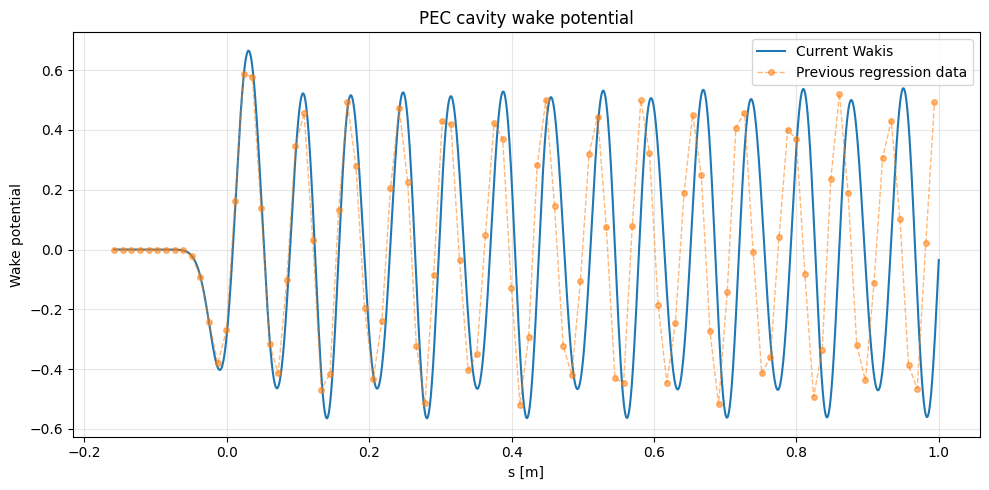

In [9]:
s_reference = wake.s[::50]

if len(s_reference) != len(WP_reference):
    raise RuntimeError(
        "Stored WP regression data do not match the current wake.s[::50] sampling."
    )

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    wake.s,
    wake.WP,
    linewidth=1.5,
    label="Current Wakis",
)

ax.plot(
    s_reference,
    WP_reference,
    linestyle="--",
    linewidth=1.0,
    alpha=0.55,
    marker="o",
    markersize=4,
    label="Previous regression data",
)

ax.set_xlabel("s [m]")
ax.set_ylabel("Wake potential")
ax.set_title("PEC cavity wake potential")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Longitudinal impedance comparison

The impedance makes shifts of the cavity resonances easier to identify.

The previous regression values are shown at the same sampled frequencies used by `test_001_pec_cubic_cavity.py`. Analytical on-axis-coupled TM resonances are added as vertical reference lines, with TM$_{110}$ highlighted separately.

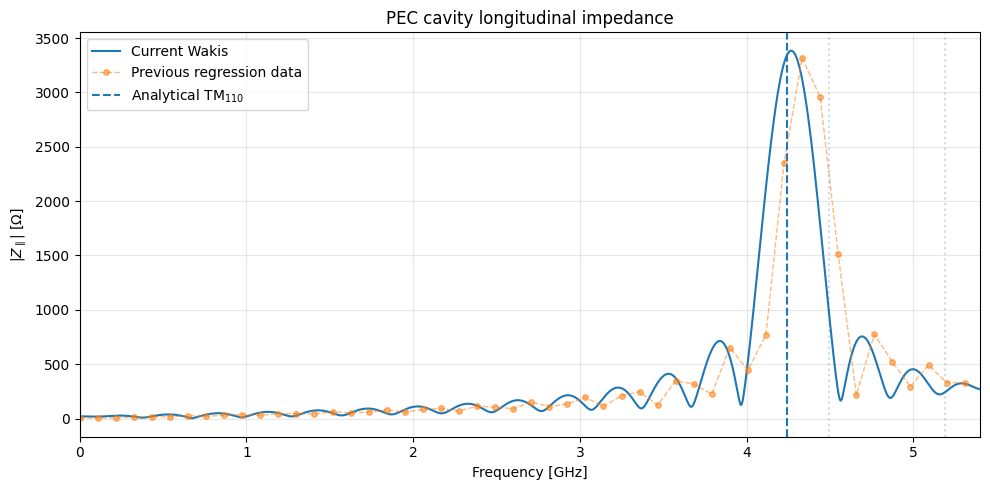

In [10]:
f_reference = wake.f[::20]

if len(f_reference) != len(Z_reference):
    raise RuntimeError(
        "Stored Z regression data do not match the current wake.f[::20] sampling."
    )

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    wake.f / 1e9,
    np.abs(wake.Z),
    linewidth=1.5,
    label="Current Wakis",
)

ax.plot(
    f_reference / 1e9,
    np.abs(Z_reference),
    linestyle="--",
    linewidth=1.0,
    alpha=0.55,
    marker="o",
    markersize=4,
    label="Previous regression data",
)

for indices, frequency in zip(tm_indices, tm_frequencies):
    if frequency > wake.f[-1]:
        break

    ax.axvline(
        frequency / 1e9,
        linestyle=":",
        alpha=0.25,
    )

ax.axvline(
    f110 / 1e9,
    linestyle="--",
    linewidth=1.5,
    label=r"Analytical TM$_{110}$",
)

ax.set_xlim(0.0, wake.f[-1] / 1e9)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"$|Z_\parallel|$ [$\Omega$]")
ax.set_title("PEC cavity longitudinal impedance")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Fundamental-mode comparison

The zoom below focuses on TM$_{110}$, the lowest on-axis-coupled TM resonance.

This is the most direct comparison between the previous regression data, the current Wakis solution, and the analytical cavity frequency.

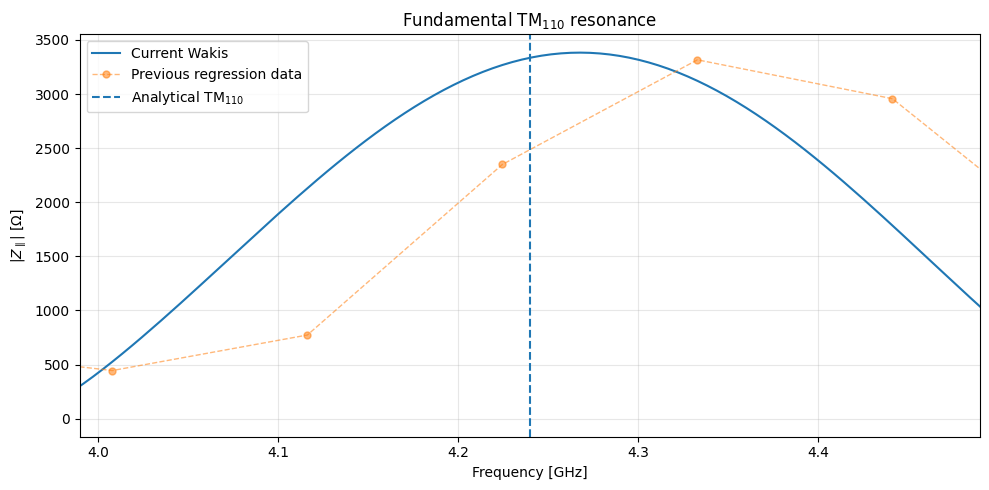

In [11]:
zoom_half_width = 0.25e9

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    wake.f / 1e9,
    np.abs(wake.Z),
    linewidth=1.5,
    label="Current Wakis",
)

ax.plot(
    f_reference / 1e9,
    np.abs(Z_reference),
    linestyle="--",
    linewidth=1.0,
    alpha=0.55,
    marker="o",
    markersize=5,
    label="Previous regression data",
)

ax.axvline(
    f110 / 1e9,
    linestyle="--",
    linewidth=1.5,
    label=r"Analytical TM$_{110}$",
)

ax.set_xlim(
    max(0.0, f110 - zoom_half_width) / 1e9,
    (f110 + zoom_half_width) / 1e9,
)

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"$|Z_\parallel|$ [$\Omega$]")
ax.set_title(r"Fundamental TM$_{110}$ resonance")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Interpretation

The previous regression data represent the solver behavior before the dual-grid and high-side PEC boundary corrections.

The comparison above is intended to distinguish an expected regression-data change from an unintended numerical regression:

- the wake potential reveals the accumulated phase difference between the old and current solutions;
- the impedance exposes the corresponding resonance-frequency shift more directly;
- the analytical rectangular-cavity resonances provide an independent physical reference.

If the corrected solver moves the numerical resonance closer to the analytical $\mathrm{TM}_{110}$ frequency, the stored regression data should be updated rather than treating the changed result as a solver failure.